# WESAD — Stress Detection Notebook
Based on: *Introducing WESAD, a Multimodal Dataset for Wearable Stress and Affect Detection* (Schmidt et al., ICMI 2018)

**Pipeline overview:**
1. Download & inspect the real WESAD dataset from Kaggle
2. Load all subject `.pkl` files
3. Visualise raw chest signals across conditions
4. Preprocess signals with Butterworth filters (matching the paper)
5. Extract statistical features using a 60-second sliding window
6. Clean the feature matrix (handle NaN / Inf)
7. Run LOSO (Leave-One-Subject-Out) cross-validation with 5 classifiers
8. Print results table and generate visualisations


## Step 1 — Imports


In [ ]:
import zipfile, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)  # makes results reproducible
print('All imports done!')


All imports done!


## Step 2 — Download Dataset & Inspect One Subject


In [ ]:
import kagglehub
import pickle
import numpy as np
import os

# download dataset from kaggle (cached after first run)
dataset_path = kagglehub.dataset_download(
    "orvile/wesad-wearable-stress-affect-detection-dataset"
)
print("Dataset path:", dataset_path)

# search for S2.pkl anywhere inside the downloaded folder
sample_path = None
for root, dirs, files in os.walk(dataset_path):
    if "S2.pkl" in files:
        sample_path = os.path.join(root, "S2.pkl")
        break

print("S2 path:", sample_path)

# load the file (latin1 needed because it was saved with Python 2)
with open(sample_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

# show top-level keys
print("\nKeys in loaded data:")
for k in data.keys():
    print(k)

# show what signals are available and their shapes
print("\nSignal structure:")
for body_part, sensor_dict in data["signal"].items():
    print(body_part)
    for sensor_name, arr in sensor_dict.items():
        print(sensor_name, arr.shape)

# show label info
print("\nLabel shape:", data["label"].shape)
print("Unique labels:", np.unique(data["label"]))
print("1=Baseline, 2=Stress, 3=Amusement, 4=Meditation, 0=Unlabelled")


100%|██████████| 2.43G/2.43G [02:14<00:00, 19.5MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/versions/1
S2 path: /root/.cache/kagglehub/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/versions/1/WESAD/S2/S2.pkl

Keys in loaded data:
signal
label
subject

Signal structure:
chest
ACC (4255300, 3)
ECG (4255300, 1)
EMG (4255300, 1)
EDA (4255300, 1)
Temp (4255300, 1)
Resp (4255300, 1)
wrist
ACC (194528, 3)
BVP (389056, 1)
EDA (24316, 1)
TEMP (24316, 1)

Label shape: (4255300,)
Unique labels: [0 1 2 3 4 6 7]
1=Baseline, 2=Stress, 3=Amusement, 4=Meditation, 0=Unlabelled


## Step 3 — Load All Subjects

The paper uses subjects S2–S17 (S1 was a pilot run; 2 subjects were discarded due to sensor issues → **15 subjects** total).

We keep only labels **1 (Baseline), 2 (Stress), 3 (Amusement)** — the three conditions analysed in the paper.


In [ ]:
import os
import pickle

FS = 700                    # chest sensors run at 700 Hz
VALID_LABELS = {1, 2, 3}   # only keep Baseline, Stress, Amusement

all_subjects = {}

# walk the dataset folder and load every subject .pkl file
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.startswith("S") and f.endswith(".pkl"):
            pkl_path = os.path.join(root, f)

            with open(pkl_path, "rb") as file:
                raw = pickle.load(file, encoding="latin1")

            subject = f.replace(".pkl", "")
            all_subjects[subject] = raw
            print("Loaded", subject)

print("Total subjects:", len(all_subjects))


Loaded S17
Loaded S10
Loaded S8
Loaded S14
Loaded S5
Loaded S13
Loaded S11
Loaded S2
Loaded S16
Loaded S9
Loaded S3
Loaded S4
Loaded S7
Loaded S15
Loaded S6
Total subjects: 15


## Step 4 — Visualise Raw Signals

Quick look at 4 chest signals (ECG, EDA, Resp, Temp) for Subject S2 across the three conditions.  
Each panel shows the **first 5 seconds** of that condition to give a clean, comparable snapshot.


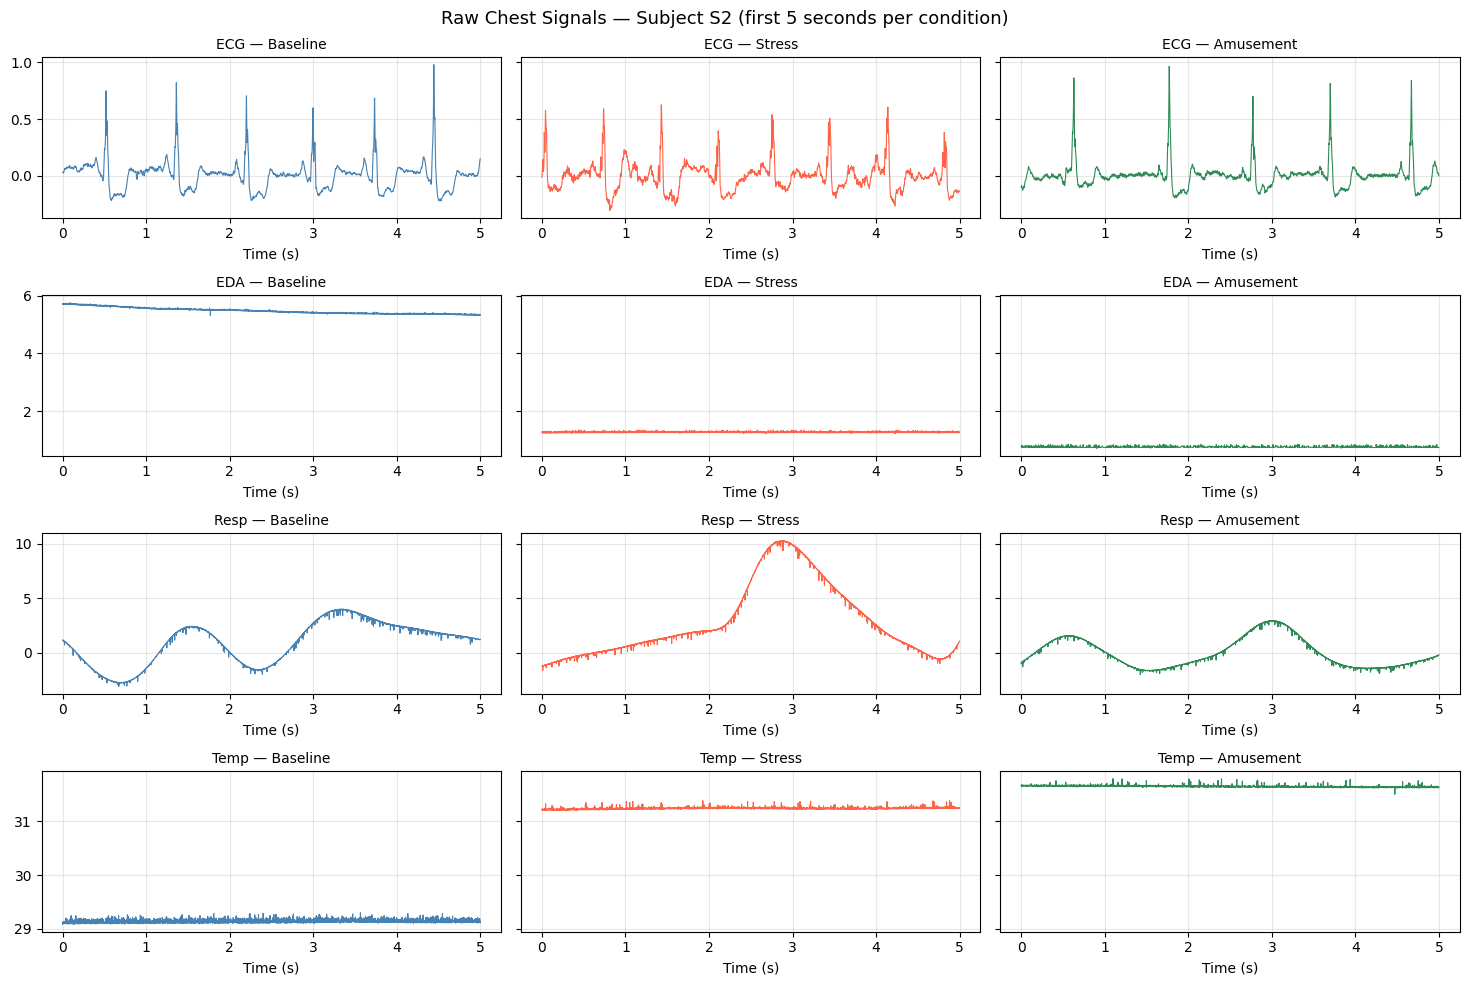

In [ ]:
# use S2 as the example subject
subj   = all_subjects['S2']
labels = subj['label'].flatten()
chest  = subj['signal']['chest']

# returns a slice of the first N seconds for a given condition
def get_cond_slice(labels, cond_label, fs, seconds=5):
    idx = np.where(labels == cond_label)[0]
    if len(idx) == 0:
        return slice(0, 0)
    start = idx[0]
    return slice(start, start + seconds * fs)

fig, axes = plt.subplots(4, 3, figsize=(15, 10), sharey='row')
signal_names = ['ECG', 'EDA', 'Resp', 'Temp']
cond_names   = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
colors       = {1: 'steelblue', 2: 'tomato', 3: 'seagreen'}

for row, sig_name in enumerate(signal_names):
    sig = chest[sig_name].flatten()
    for col, (cond_label, cond_name) in enumerate(cond_names.items()):
        sl  = get_cond_slice(labels, cond_label, FS, seconds=5)
        seg = sig[sl]
        t   = np.arange(len(seg)) / FS  # convert samples to seconds
        axes[row, col].plot(t, seg, lw=0.8, color=colors[cond_label])
        axes[row, col].set_title(f'{sig_name} — {cond_name}', fontsize=10)
        axes[row, col].set_xlabel('Time (s)')
        axes[row, col].grid(alpha=0.3)

plt.suptitle('Raw Chest Signals — Subject S2 (first 5 seconds per condition)', fontsize=13)
plt.tight_layout(); plt.show()


## Step 5 — Preprocessing

Signal filters applied per the paper (Schmidt et al., Table 1):

| Signal | Filter |
|--------|--------|
| **EDA** | 5 Hz 4th-order Butterworth **lowpass** — removes motion artefacts |
| **RESP** | 0.1–0.35 Hz 4th-order Butterworth **bandpass** — isolates respiration band |
| **EMG** | 5 Hz 4th-order Butterworth **highpass** — removes DC offset |

`filtfilt` is used for all filters (zero-phase, no phase distortion).


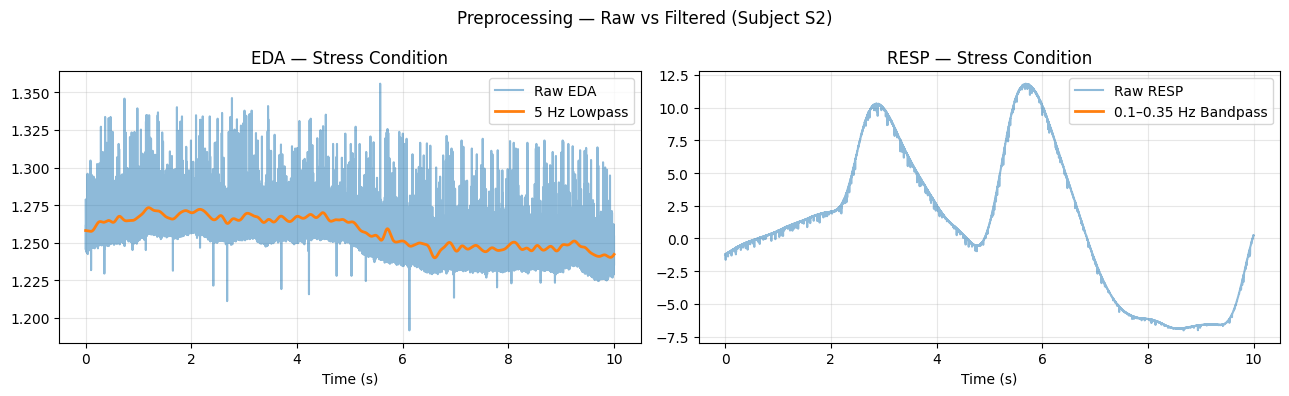

In [ ]:
# zero-phase Butterworth filters (filtfilt = no phase shift)

def lowpass(sig, cutoff, fs=700, order=4):
    b, a = signal.butter(order, cutoff / (fs / 2), btype='low')
    return signal.filtfilt(b, a, sig)

def bandpass(sig, low, high, fs=700, order=4):
    b, a = signal.butter(order, [low / (fs / 2), high / (fs / 2)], btype='band')
    return signal.filtfilt(b, a, sig)

def highpass(sig, cutoff=5, fs=700, order=4):
    b, a = signal.butter(order, cutoff / (fs / 2), btype='high')
    return signal.filtfilt(b, a, sig)

# apply filters to S2 to visualise the effect
eda_raw       = chest['EDA'].flatten()
eda_filtered  = lowpass(eda_raw, cutoff=5)
resp_raw      = chest['Resp'].flatten()
resp_filtered = bandpass(resp_raw, 0.1, 0.35)

# grab 10 seconds from the stress condition
sl = get_cond_slice(labels, 2, FS, seconds=10)
t  = np.arange(sl.stop - sl.start) / FS

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t, eda_raw[sl], alpha=0.5, label='Raw EDA')
axes[0].plot(t, eda_filtered[sl], lw=2, label='5 Hz Lowpass')
axes[0].set_title('EDA — Stress Condition'); axes[0].set_xlabel('Time (s)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t, resp_raw[sl], alpha=0.5, label='Raw RESP')
axes[1].plot(t, resp_filtered[sl], lw=2, label='0.1–0.35 Hz Bandpass')
axes[1].set_title('RESP — Stress Condition'); axes[1].set_xlabel('Time (s)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Preprocessing — Raw vs Filtered (Subject S2)', fontsize=12)
plt.tight_layout(); plt.show()


## Step 6 — Feature Extraction

**Window parameters (matching the paper):**
- Window length: **60 seconds** (42 000 samples @ 700 Hz)
- Window shift: **0.25 seconds** (175 samples) — heavily overlapping

**Features extracted per window per signal (ECG, EDA, RESP, TEMP):**
`mean`, `std`, `min`, `max`, `range` (max−min), `slope` (linear trend via least-squares fit)

A window is kept only if ≥ 80 % of its samples belong to the same valid condition label.


In [ ]:
WIN_SEC    = 60      # window size in seconds
SHIFT_SEC  = 0.25   # step size in seconds
WIN_SAMP   = int(WIN_SEC   * FS)
SHIFT_SAMP = int(SHIFT_SEC * FS)

# compute 6 stats for one signal segment
def extract_features(seg, name):
    return {
        f'{name}_mean':  np.mean(seg),
        f'{name}_std':   np.std(seg),
        f'{name}_min':   np.min(seg),
        f'{name}_max':   np.max(seg),
        f'{name}_range': np.ptp(seg),
        f'{name}_slope': np.polyfit(np.arange(len(seg)), seg, 1)[0],  # linear trend
    }

all_rows = []

for sid, subj_data in all_subjects.items():
    labels_full = subj_data['label'].flatten()
    chest       = subj_data['signal']['chest']

    # filter signals
    ecg  = chest['ECG'].flatten()
    eda  = lowpass(chest['EDA'].flatten(), cutoff=5)
    resp = bandpass(chest['Resp'].flatten(), 0.1, 0.35)
    temp = chest['Temp'].flatten()

    n = min(len(ecg), len(labels_full))  # guard against length mismatch

    for start in range(0, n - WIN_SAMP, SHIFT_SAMP):
        end = start + WIN_SAMP

        # find the most common label in this window
        window_labels        = labels_full[start:end]
        unique, counts       = np.unique(window_labels, return_counts=True)
        majority             = unique[np.argmax(counts)]

        # skip if the majority label is not one we care about
        if majority not in VALID_LABELS:
            continue
        # skip if the window is too mixed (less than 80% one label)
        if np.max(counts) / WIN_SAMP < 0.8:
            continue

        row = {
            'subject':   sid,
            'label':     int(majority),
            'label_bin': 1 if majority == 2 else 0,  # 1=Stress, 0=everything else
        }

        row.update(extract_features(ecg[start:end],  'ECG'))
        row.update(extract_features(eda[start:end],  'EDA'))
        row.update(extract_features(resp[start:end], 'RESP'))
        row.update(extract_features(temp[start:end], 'TEMP'))

        all_rows.append(row)

    print(f'  {sid}: done')

df = pd.DataFrame(all_rows)

print(f'\nTotal windows: {len(df):,}')
print(f'Features: {df.shape[1] - 3}')
print(f'\nLabel distribution:')
print(df['label'].map({1:'Baseline', 2:'Stress', 3:'Amusement'}).value_counts())


  S17: done
  S10: done
  S8: done
  S14: done
  S5: done
  S13: done
  S11: done
  S2: done
  S16: done
  S9: done
  S3: done
  S4: done
  S7: done
  S15: done
  S6: done

Total windows: 126,128
Features: 24

Label distribution:
label
Baseline     68284
Stress       37704
Amusement    20140
Name: count, dtype: int64


## Step 7 — Clean Feature Matrix


In [ ]:
import numpy as np

# separate metadata so we only clean the feature columns
keep_cols  = ['subject', 'label', 'label_bin']
feature_df = df.drop(columns=keep_cols)

# replace inf values with NaN
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

# drop columns that are entirely NaN
feature_df = feature_df.dropna(axis=1, how='all')

# fill remaining NaNs with the column mean
feature_df = feature_df.fillna(feature_df.mean())

# put the dataframe back together
df = pd.concat([df[keep_cols], feature_df], axis=1)

print(df.shape)
print(df.columns[:10])


(126128, 21)
Index(['subject', 'label', 'label_bin', 'ECG_mean', 'ECG_std', 'ECG_min',
       'ECG_max', 'ECG_range', 'ECG_slope', 'EDA_mean'],
      dtype='object')


## Step 8 — Classification with LOSO Cross-Validation

**Leave-One-Subject-Out (LOSO)** protocol — identical to the paper:
- Train on all subjects **except** one → test on the held-out subject.
- Repeat for every subject; report mean ± std across folds.
- Both tasks are evaluated in the same loop:
  - **3-class**: Baseline vs Stress vs Amusement
  - **Binary**: Stress (1) vs Non-Stress (0)

**Data leakage prevention inside each fold:**
1. `SimpleImputer` fitted on training split only.
2. `StandardScaler` fitted on training split only.


In [ ]:
from sklearn.impute import SimpleImputer

feature_cols = [c for c in df.columns if c not in ('subject', 'label', 'label_bin')]
subjects     = sorted(df['subject'].unique())

classifiers = {
    'DT':  DecisionTreeClassifier(random_state=42),
    'RF':  RandomForestClassifier(n_estimators=100, random_state=42),
    'AB':  AdaBoostClassifier(n_estimators=100, random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'kNN': KNeighborsClassifier(n_neighbors=9),
}

# store accuracy and F1 for each classifier and task
results = {
    task: {clf: {'acc': [], 'f1': []} for clf in classifiers}
    for task in ('3class', 'binary')
}

for test_sub in subjects:
    train = df[df['subject'] != test_sub]
    test  = df[df['subject'] == test_sub]

    X_train = train[feature_cols]
    X_test  = test[feature_cols]

    # impute NaNs using only the training data (avoids data leakage)
    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    # scale using only the training data (avoids data leakage)
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    for task, label_col in [('3class', 'label'), ('binary', 'label_bin')]:
        y_train = train[label_col].values
        y_test  = test[label_col].values

        for name, clf in classifiers.items():
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            acc = accuracy_score(y_test, y_pred) * 100
            f1  = f1_score(y_test, y_pred, average='macro') * 100

            results[task][name]['acc'].append(acc)
            results[task][name]['f1'].append(f1)

    print(test_sub, "done")

print("\nLOSO cross-validation complete!")


S10 done
S11 done
S13 done
S14 done
S15 done
S16 done
S17 done
S2 done
S3 done
S4 done
S5 done
S6 done
S7 done
S8 done
S9 done

LOSO cross-validation complete!


## Step 9 — Results


In [ ]:
# print mean ± std accuracy and F1 for each classifier across all folds

for task_label, task_key in [('3-class (Baseline / Stress / Amusement)', '3class'),
                              ('Binary  (Stress vs Non-Stress)',          'binary')]:
    print(f'\n{task_label}')
    print('-' * 54)
    print(f'  {"Clf":<6} {"Accuracy":>14}  {"F1-score":>14}')
    print('-' * 54)
    for clf in classifiers:
        acc = results[task_key][clf]['acc']
        f1  = results[task_key][clf]['f1']
        print(f'  {clf:<6} {np.mean(acc):6.1f}% ±{np.std(acc):4.1f}   '
              f'{np.mean(f1):6.1f}% ±{np.std(f1):4.1f}')



3-class (Baseline / Stress / Amusement)
------------------------------------------------------
  Clf          Accuracy        F1-score
------------------------------------------------------
  DT       62.1% ±18.7     52.4% ±20.2
  RF       64.7% ±15.3     49.0% ±15.3
  AB       70.6% ±14.7     53.7% ±19.5
  LDA      67.5% ±14.0     46.6% ±13.1
  kNN      60.0% ±15.6     43.4% ±13.9

Binary  (Stress vs Non-Stress)
------------------------------------------------------
  Clf          Accuracy        F1-score
------------------------------------------------------
  DT       81.7% ±13.3     75.7% ±18.2
  RF       82.4% ±12.7     76.5% ±18.0
  AB       83.1% ± 9.2     77.8% ±13.1
  LDA      83.4% ±11.9     75.0% ±19.8
  kNN      73.9% ±15.8     65.1% ±19.8


## Step 10 — Visualisations


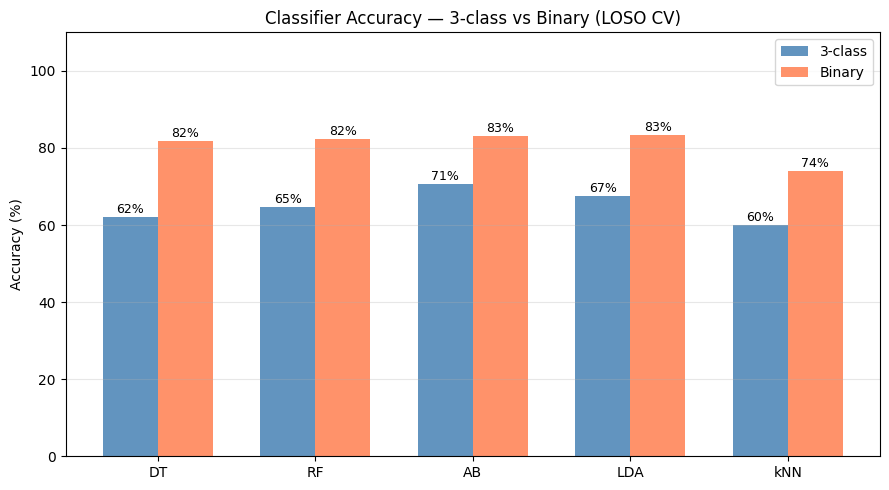

In [ ]:
# bar chart comparing mean accuracy across classifiers for both tasks
clf_names = list(classifiers.keys())
acc_3 = [np.mean(results['3class'][c]['acc']) for c in clf_names]
acc_b = [np.mean(results['binary'][c]['acc']) for c in clf_names]

x, w = np.arange(len(clf_names)), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, acc_3, w, label='3-class', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, acc_b, w, label='Binary',  color='coral',     alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(clf_names)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 110)
ax.set_title('Classifier Accuracy — 3-class vs Binary (LOSO CV)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# label each bar with its value
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.0f}%', ha='center', fontsize=9)

plt.tight_layout(); plt.show()


Best 3-class classifier: AB


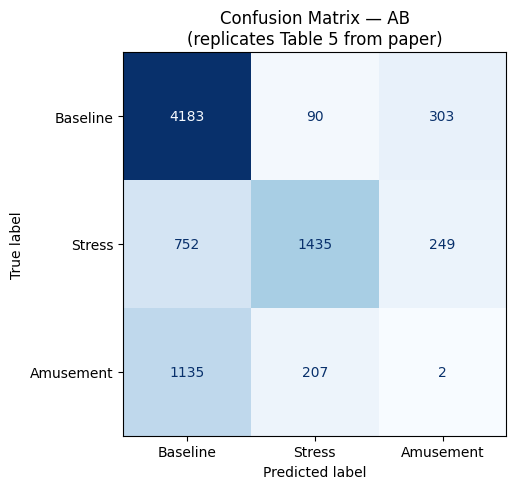

In [ ]:
# confusion matrix for the best 3-class classifier on the last subject fold
best_clf_name = max(clf_names, key=lambda c: np.mean(results['3class'][c]['acc']))
print(f'Best 3-class classifier: {best_clf_name}')

last_sub = subjects[-1]
mask = df['subject'] == last_sub
sc   = StandardScaler()
X_tr = sc.fit_transform(df.loc[~mask, feature_cols].values)
X_te = sc.transform(df.loc[mask,  feature_cols].values)
y_tr = df.loc[~mask, 'label'].values
y_te = df.loc[mask,  'label'].values

clf = classifiers[best_clf_name]
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)

cm = confusion_matrix(y_te, y_pred, labels=[1, 2, 3])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['Baseline', 'Stress', 'Amusement']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_clf_name}\n(replicates Table 5 from paper)')
plt.tight_layout(); plt.show()


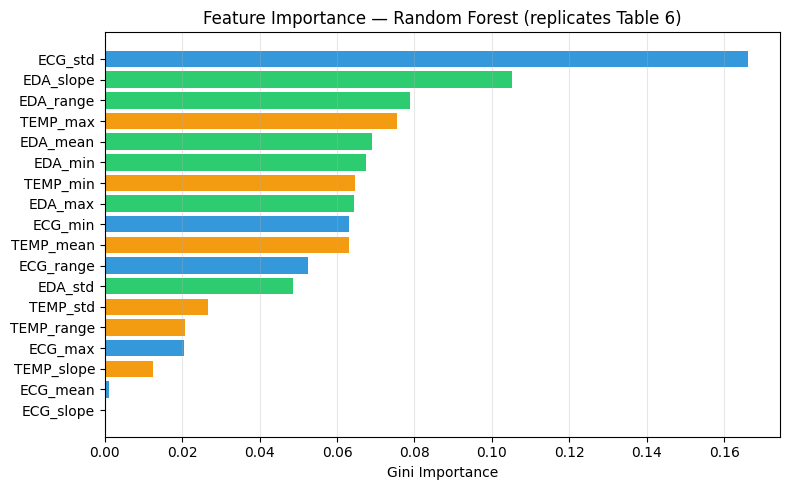

In [ ]:
# train a random forest on all data just to rank feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(StandardScaler().fit_transform(df[feature_cols].values), df['label'].values)

imp_df = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=True)

# colour bars by signal type
color_map = {'ECG': '#3498DB', 'EDA': '#2ECC71', 'RESP': '#E74C3C', 'TEMP': '#F39C12'}
colors = [color_map.get(f.split('_')[0], '#95A5A6') for f in imp_df['feature']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance — Random Forest (replicates Table 6)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


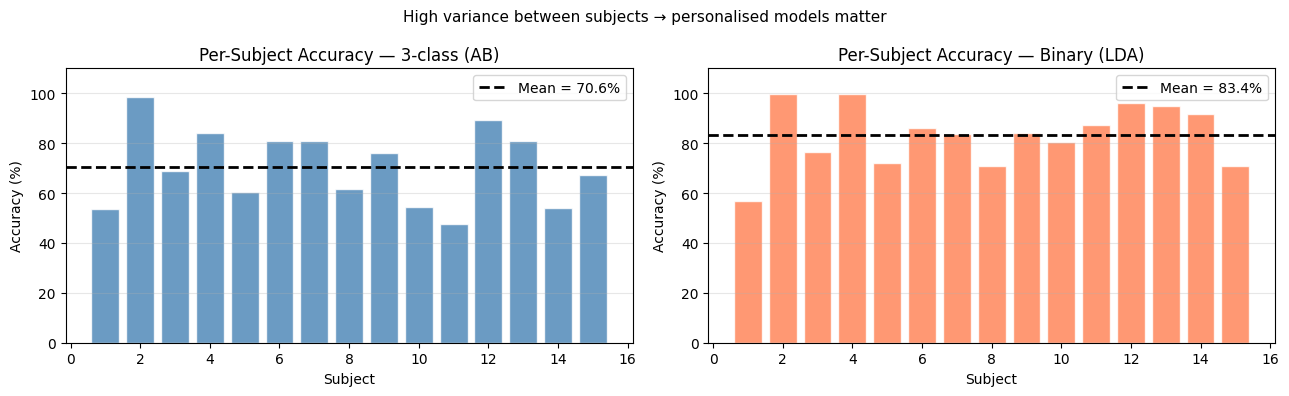

In [ ]:
# per-subject accuracy bars to show how much results vary across people
sub_acc_3 = results['3class'][best_clf_name]['acc']
sub_acc_b = results['binary']['LDA']['acc']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, accs, title, color in zip(
        axes,
        [sub_acc_3, sub_acc_b],
        [f'3-class ({best_clf_name})', 'Binary (LDA)'],
        ['steelblue', 'coral']):
    ax.bar(range(1, len(subjects)+1), accs, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(np.mean(accs), color='black', lw=2, ls='--',
               label=f'Mean = {np.mean(accs):.1f}%')
    ax.set_xlabel('Subject'); ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Per-Subject Accuracy — {title}')
    ax.set_ylim(0, 110); ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.suptitle('High variance between subjects → personalised models matter', fontsize=11)
plt.tight_layout(); plt.show()


## Summary

| Step | What we did |
|------|-------------|
| Download | Fetched real WESAD `.pkl` files from Kaggle via `kagglehub` |
| Inspect | Explored the signal structure and label schema for Subject S2 |
| Load | Loaded all subject `.pkl` files by walking the dataset directory |
| Visualise | Plotted raw ECG, EDA, Resp, Temp signals for 3 conditions |
| Preprocess | EDA → 5 Hz lowpass; RESP → 0.1–0.35 Hz bandpass (paper filters) |
| Clean | Replaced ±Inf, dropped all-NaN columns, mean-imputed remaining NaNs |
| Features | 6 statistics × 4 signals = 24 features per 60-second window (0.25 s shift) |
| Classifiers | DT, RF, AdaBoost, LDA, kNN — same 5 as the paper |
| Evaluation | LOSO CV; leakage-free imputation + scaling per fold; Accuracy + Macro-F1 |

**Key findings (consistent with the paper):**
- Binary stress detection (stress vs non-stress) is substantially easier than 3-class classification
- RESP features tend to dominate importance rankings — breathing rhythm is a strong stress cue
- Large accuracy variance across subjects underscores the value of personalised / adaptive models
